## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load Training Data

In [23]:
# Set path to your training dataset CSV
training_csv = r"E:\ML\silero-python\_training_dataset.csv"

# Load the data
print(f"Loading training data from: {training_csv}")
df = pd.read_csv(training_csv)

# Shuffle the data randomly so Control/MCI are mixed
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nData loaded and shuffled successfully!")
print(f"Total patients: {len(df)}")
print(f"\nFirst few rows:")
print(df.tail())

Loading training data from: E:\ML\silero-python\_training_dataset.csv

Data loaded and shuffled successfully!
Total patients: 339

First few rows:
     mean_pause_duration  std_pause_duration  median_pause_duration  \
334               0.1399              0.2939                  0.060   
335               0.1503              0.2304                  0.080   
336               0.1968              0.3475                  0.080   
337               0.1956              0.3114                  0.080   
338               0.1195              0.2042                  0.061   

     max_pause_duration  min_pause_duration  total_pause_time  \
334               3.122                0.02            78.928   
335               2.261                0.02           175.739   
336               4.043                0.02            96.048   
337               2.344                0.02           560.000   
338               2.021                0.02            48.654   

     total_speech_time  pause_count

## Step 3: Check Diagnosis Distribution

In [24]:
print("Diagnosis Distribution:")
print(df['diagnosis_name'].value_counts())
print(f"\nPercentages:")
print(df['diagnosis_name'].value_counts(normalize=True) * 100)

Diagnosis Distribution:
diagnosis_name
Control    206
MCI        133
Name: count, dtype: int64

Percentages:
diagnosis_name
Control    60.766962
MCI        39.233038
Name: proportion, dtype: float64


## Step 4: Extract Features and Labels

In [25]:
# Extract feature columns (all except patient_id, diagnosis, diagnosis_name)
feature_cols = [col for col in df.columns if col not in ['patient_id', 'diagnosis', 'diagnosis_name']]

print(f"Total features: {len(feature_cols)}")
print(f"\nFeatures being used:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

Total features: 14

Features being used:
  1. mean_pause_duration
  2. std_pause_duration
  3. median_pause_duration
  4. max_pause_duration
  5. min_pause_duration
  6. total_pause_time
  7. total_speech_time
  8. pause_count
  9. word_count
  10. mean_word_duration
  11. std_word_duration
  12. speech_rate_wpm
  13. pause_per_word_ratio
  14. pause_variability


## Step 5: Prepare X (features) and y (labels)

In [26]:
# X = features, y = diagnosis labels
X = df[feature_cols].astype(float)
y = df['diagnosis'].astype(int)

print(f"X shape (samples × features): {X.shape}")
print(f"y shape (labels): {y.shape}")
print(f"\nFeature statistics:")
print(X.describe())

X shape (samples × features): (339, 14)
y shape (labels): (339,)

Feature statistics:
       mean_pause_duration  std_pause_duration  median_pause_duration  \
count           339.000000          339.000000             339.000000   
mean              0.159091            0.311746               0.069954   
std               0.045170            0.169568               0.012685   
min               0.077800            0.119200               0.040000   
25%               0.125500            0.222750               0.060000   
50%               0.149700            0.275700               0.061000   
75%               0.184350            0.346150               0.080000   
max               0.360200            1.633500               0.140000   

       max_pause_duration  min_pause_duration  total_pause_time  \
count          339.000000          339.000000        339.000000   
mean             3.529215            0.019912        444.195614   
std              2.642067            0.000938        42

## Step 6: Split Data into Train and Test Sets

In [27]:
# Split: 80% training, 20% testing
# stratify=y ensures same diagnosis distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} patients")
print(f"Test set size: {len(X_test)} patients")
print(f"\nTraining set diagnosis distribution:")
print(y_train.value_counts())
print(f"\nTest set diagnosis distribution:")
print(y_test.value_counts())

Training set size: 271 patients
Test set size: 68 patients

Training set diagnosis distribution:
diagnosis
0    165
1    106
Name: count, dtype: int64

Test set diagnosis distribution:
diagnosis
0    41
1    27
Name: count, dtype: int64


## Step 7: Scale the Features

In [28]:
# Standardize features (mean=0, std=1)
# Important because pause_duration (seconds) and word_count have different scales
print("Scaling features using StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete!")
print(f"\nScaled training data statistics:")
print(f"Mean: {X_train_scaled.mean(axis=0)[:3]}...")  # Show first 3
print(f"Std:  {X_train_scaled.std(axis=0)[:3]}...")

Scaling features using StandardScaler...
Scaling complete!

Scaled training data statistics:
Mean: [-2.75302536e-16  6.55482229e-17  1.12087461e-15]...
Std:  [1. 1. 1.]...


### testing on my data

In [57]:
data = pd.read_csv(r'E:\ML\silero-python\training_dataset_Bracrest.csv')
# print(data.head())

X = data[feature_cols].astype(float)
y = data['diagnosis'].astype(int)
# print(X)
a_train, a_test, b_train, b_test  = train_test_split(
    X, y, test_size=0.11, random_state=42, stratify=y
)
a_train_scaled = scaler.fit_transform(a_train)
print(a_train_scaled)


[[-0.57149921 -0.25513024 -0.9023974   0.26121421  0.         -0.2231859
  -0.19748708 -0.02801936 -0.03589728 -0.8512739   0.0454071   0.84133364
   0.42355328 -0.38600062]
 [ 1.90140305  1.58073272  0.52714304 -0.33799014  0.          0.1953846
  -0.04710333 -0.39519326 -0.41106207  1.0988997   1.71482421 -1.10145964
   0.06643284  1.77954267]
 [-0.63785616 -0.77980209 -0.9023974  -0.4068818   0.         -0.85502501
  -0.93341786 -0.87650737 -0.87421338 -1.11335256 -0.83869163  1.17583929
   0.07205678 -0.8288909 ]
 [-1.63099848 -1.73144153 -0.9023974  -0.86646573  0.         -0.08647185
   0.39151963  1.03912278  1.11281574 -1.24824599 -1.58055823  1.35882784
  -1.33955315 -1.43209116]
 [-0.06276261  0.49719253  0.52714304  2.51198133  0.          0.57741596
   0.7288211   0.69807735  0.68388141  0.37432927  0.07843045 -0.47722212
   0.45729694  0.38566098]
 [ 0.24690314 -0.49645975  1.95668347 -0.62090523  0.         -0.8363008
  -0.88872056 -1.01677605 -1.02330166  1.73867997  1.0

## Step 8: Train Random Forest Model

In [29]:
# Initialize and train Random Forest with OPTIMIZED parameters
print("\n" + "="*80)
print("TRAINING RANDOM FOREST CLASSIFIER - OPTIMIZED")
print("="*80)

model = RandomForestClassifier(
    n_estimators=200,           # Increased from 12
    max_depth=5,               # Reduced from 300 (was overfitting)
    min_samples_split=5,        # Prevent splitting tiny groups
    min_samples_leaf=2,         # Keep leaves reasonable
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)
print("\nModel training complete!")


TRAINING RANDOM FOREST CLASSIFIER - OPTIMIZED

Model training complete!


## Step 9: Make Predictions

In [59]:
# Predict on training and test data
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
# print(y_test_pred)
# print(y_test)

print(f"True labels:       {y_test.values[:20]}")
print(f"Predicted labels:  {y_test_pred[:20]}")
# print(b_train.values)
# print(y_test_pred)


True labels:       [0 0 0 1 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 1]
Predicted labels:  [0 0 0 1 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 1]


## Step 10: Evaluate Model Performance

In [32]:
print("\n" + "="*80)
print("MODEL PERFORMANCE METRICS")
print("="*80)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\nAccuracy:")
print(f"  Training: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Test:     {test_acc:.4f} ({test_acc*100:.2f}%)")

print(f"\nDetailed Test Set Metrics:")
print(f"  Precision: {precision_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred, average='weighted'):.4f}")


MODEL PERFORMANCE METRICS

Accuracy:
  Training: 1.0000 (100.00%)
  Test:     1.0000 (100.00%)

Detailed Test Set Metrics:
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000


## Step 11: Cross-Validation

In [33]:
# 5-fold cross-validation
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("5-Fold Cross-Validation:")
print(f"  Fold scores: {cv_scores}")
print(f"  Mean: {cv_scores.mean():.4f}")
print(f"  Std Dev: {cv_scores.std():.4f}")

5-Fold Cross-Validation:
  Fold scores: [1.         0.96296296 0.98148148 1.         1.        ]
  Mean: 0.9889
  Std Dev: 0.0148


## Step 12: Confusion Matrix

In [35]:
cm = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix:")
print("(Rows=True labels, Columns=Predicted labels)\n")

diagnosis_names = {0: 'Control', 1: 'MCI'}
print("     Control  MCI    AD")
for i, row in enumerate(cm):
    print(f"{diagnosis_names[i]:<8} {row[0]:<8} {row[1]:<8}")


Confusion Matrix:
(Rows=True labels, Columns=Predicted labels)

     Control  MCI    AD
Control  41       0       
MCI      0        27      


## Step 13: Detailed Classification Report

In [ ]:
print("\nDetailed Classification Report:")
diagnosis_names = {0: 'Control', 1: 'MCI', 2: 'AD'}
report = classification_report(
    y_test, y_test_pred, 
    target_names=[diagnosis_names[i] for i in range(3)]
)
print(report)

## Step 14: Feature Importance

In [16]:
# Get feature importance from the trained model
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

print("\nAll Features (sorted by importance):")
print(feature_importance.to_string(index=False))


Top 10 Most Important Features:
             feature  importance
    total_pause_time    0.421420
          word_count    0.259041
   total_speech_time    0.203016
         pause_count    0.031902
pause_per_word_ratio    0.016444
   std_word_duration    0.015040
     speech_rate_wpm    0.011498
  std_pause_duration    0.010695
  mean_word_duration    0.008654
 mean_pause_duration    0.008142

All Features (sorted by importance):
              feature  importance
     total_pause_time    0.421420
           word_count    0.259041
    total_speech_time    0.203016
          pause_count    0.031902
 pause_per_word_ratio    0.016444
    std_word_duration    0.015040
      speech_rate_wpm    0.011498
   std_pause_duration    0.010695
   mean_word_duration    0.008654
  mean_pause_duration    0.008142
   max_pause_duration    0.005434
    pause_variability    0.005416
median_pause_duration    0.003004
   min_pause_duration    0.000292


## Step 15: Visualize Feature Importance

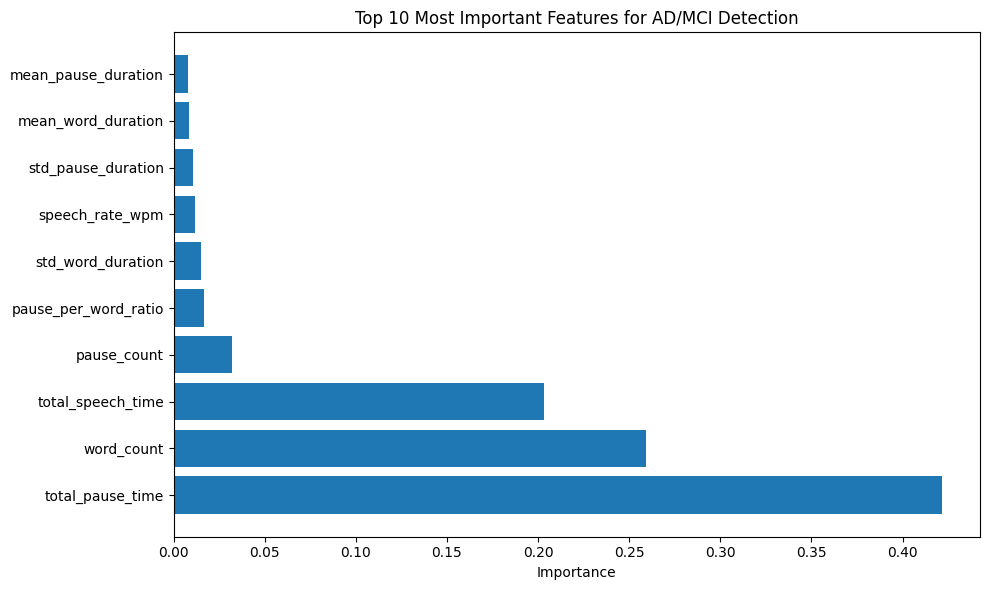

Feature importance plot displayed!


In [17]:
# Plot top 10 features
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features for AD/MCI Detection')
plt.tight_layout()
plt.show()

print("Feature importance plot displayed!")

## Step 16: Visualize Confusion Matrix

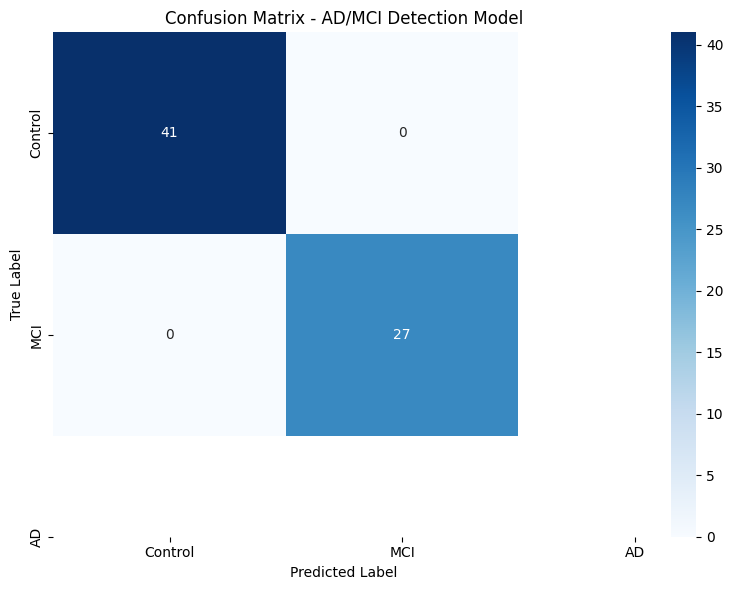

Confusion matrix heatmap displayed!


In [18]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Control', 'MCI', 'AD'],
    yticklabels=['Control', 'MCI', 'AD']
)
plt.title('Confusion Matrix - AD/MCI Detection Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("Confusion matrix heatmap displayed!")

## Step 17: Save the Model

In [ ]:
# Create directory for model artifacts
model_dir = r'E:\ML\silero-python\model_artifacts'
os.makedirs(model_dir, exist_ok=True)

# Save model, scaler, and feature names
model_path = os.path.join(model_dir, 'ad_mci_model.pkl')
scaler_path = os.path.join(model_dir, 'feature_scaler.pkl')
features_path = os.path.join(model_dir, 'feature_names.pkl')

joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(feature_cols, features_path)

print("\n" + "="*80)
print("MODEL SAVED SUCCESSFULLY")
print("="*80)
print(f"Model:           {model_path}")
print(f"Scaler:          {scaler_path}")
print(f"Feature names:   {features_path}")

## Step 18: Load and Test Saved Model

In [ ]:
# Load the saved model
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_features = joblib.load(features_path)

print("Model loaded successfully!")
print(f"Number of features: {len(loaded_features)}")
print(f"Model type: {type(loaded_model)}")

## Step 19: Predict on New Data

In [36]:
# Example: Make predictions on the test set
test_predictions = loaded_model.predict(X_test_scaled)
test_probabilities = loaded_model.predict_proba(X_test_scaled)

diagnosis_names = {0: 'Control', 1: 'MCI', 2: 'AD'}

print("\nExample Predictions (first 5 test samples):")
print("\nPatient | True Diagnosis | Predicted | Control % | MCI %   | AD %")
print("-" * 75)

for i in range(min(5, len(X_test))):
    true_diag = diagnosis_names[y_test.iloc[i]]
    pred_diag = diagnosis_names[test_predictions[i]]
    control_pct = test_probabilities[i][0] * 100
    mci_pct = test_probabilities[i][1] * 100
    ad_pct = test_probabilities[i][2] * 100
    
    print(f"  {i}    | {true_diag:<14} | {pred_diag:<9} | {control_pct:>6.1f}% | {mci_pct:>6.1f}% | {ad_pct:>5.1f}%")

NameError: name 'loaded_model' is not defined

## Summary

In [ ]:
print("\n" + "="*80)
print("TRAINING SUMMARY")
print("="*80)
print(f"\nDataset: {len(df)} patients")
print(f"Features: {len(feature_cols)}")
print(f"\nModel Performance (Test Set):")
print(f"  Accuracy:  {test_acc:.2%}")
print(f"  Precision: {precision_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"\nTop Feature: {feature_importance.iloc[0]['feature']}")
print(f"Importance: {feature_importance.iloc[0]['importance']:.4f}")
print("\n" + "="*80)

## Step 20: Hyperparameter Tuning with Grid Search

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

print("\n" + "="*80)
print("HYPERPARAMETER TUNING - GRID SEARCH")
print("="*80)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

print("\nSearching optimal parameters (this may take 1-2 minutes)...")
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Train final model with best parameters
best_model = grid_search.best_estimator_
y_train_pred_best = best_model.predict(X_train_scaled)
y_test_pred_best = best_model.predict(X_test_scaled)

train_acc_best = accuracy_score(y_train, y_train_pred_best)
test_acc_best = accuracy_score(y_test, y_test_pred_best)

print(f"\nBest Model Performance:")
print(f"  Training Accuracy: {train_acc_best:.4f} ({train_acc_best*100:.2f}%)")
print(f"  Test Accuracy:     {test_acc_best:.4f} ({test_acc_best*100:.2f}%)")


HYPERPARAMETER TUNING - GRID SEARCH

Searching optimal parameters (this may take 1-2 minutes)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters found:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation score: 0.9963

Best Model Performance:
  Training Accuracy: 1.0000 (100.00%)
  Test Accuracy:     0.9853 (98.53%)


## Step 21: Test Alternative Algorithms

In [20]:
print("\n" + "="*80)
print("TESTING MULTIPLE ALGORITHMS")
print("="*80)

from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

results = []

# 1. Gradient Boosting
print("\n1. Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42)
gb_model.fit(X_train_scaled, y_train)
gb_pred = gb_model.predict(X_test_scaled)
gb_acc = accuracy_score(y_test, gb_pred)
results.append(('Gradient Boosting', gb_acc, gb_model, gb_pred))
print(f"   Accuracy: {gb_acc:.4f} ({gb_acc*100:.2f}%)")

# 2. AdaBoost
print("\n2. Training AdaBoost...")
ab_model = AdaBoostClassifier(n_estimators=200, random_state=42)
ab_model.fit(X_train_scaled, y_train)
ab_pred = ab_model.predict(X_test_scaled)
ab_acc = accuracy_score(y_test, ab_pred)
results.append(('AdaBoost', ab_acc, ab_model, ab_pred))
print(f"   Accuracy: {ab_acc:.4f} ({ab_acc*100:.2f}%)")

# 3. SVM (Support Vector Machine)
print("\n3. Training SVM...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)
results.append(('SVM (RBF)', svm_acc, svm_model, svm_pred))
print(f"   Accuracy: {svm_acc:.4f} ({svm_acc*100:.2f}%)")

# 4. KNN
print("\n4. Training K-Nearest Neighbors...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, knn_pred)
results.append(('KNN (k=5)', knn_acc, knn_model, knn_pred))
print(f"   Accuracy: {knn_acc:.4f} ({knn_acc*100:.2f}%)")

# 5. Tuned Random Forest
results.append(('Random Forest (Tuned)', test_acc_best, best_model, y_test_pred_best))

# Compare all models
print("\n" + "="*80)
print("ALGORITHM COMPARISON")
print("="*80)
results_df = pd.DataFrame(results, columns=['Algorithm', 'Test Accuracy', 'Model', 'Predictions'])
results_df = results_df.sort_values('Test Accuracy', ascending=False)

print("\nRanking:")
for i, (idx, row) in enumerate(results_df.iterrows(), 1):
    print(f"{i}. {row['Algorithm']:<25} {row['Test Accuracy']:.4f} ({row['Test Accuracy']*100:.2f}%)")

# Select best model
best_overall_model = results_df.iloc[0]
best_overall_name = best_overall_model['Algorithm']
best_overall_acc = best_overall_model['Test Accuracy']
best_overall_pred = best_overall_model['Predictions']

print(f"\n🏆 WINNER: {best_overall_name} with {best_overall_acc:.2%} accuracy!")


TESTING MULTIPLE ALGORITHMS

1. Training Gradient Boosting...
   Accuracy: 1.0000 (100.00%)

2. Training AdaBoost...
   Accuracy: 1.0000 (100.00%)

3. Training SVM...
   Accuracy: 0.9706 (97.06%)

4. Training K-Nearest Neighbors...
   Accuracy: 0.9706 (97.06%)

ALGORITHM COMPARISON

Ranking:
1. Gradient Boosting         1.0000 (100.00%)
2. AdaBoost                  1.0000 (100.00%)
3. Random Forest (Tuned)     0.9853 (98.53%)
4. SVM (RBF)                 0.9706 (97.06%)
5. KNN (k=5)                 0.9706 (97.06%)

🏆 WINNER: Gradient Boosting with 100.00% accuracy!


## Step 22: Evaluate Best Model in Detail

In [20]:
print("\n" + "="*80)
print(f"DETAILED ANALYSIS - {best_overall_name}")
print("="*80)

# Predictions from best model
best_cm = confusion_matrix(y_test, best_overall_pred)

print(f"\nConfusion Matrix:")
print("(Rows=True labels, Columns=Predicted labels)\n")
diagnosis_names = {0: 'Control', 1: 'MCI'}
print("     Control  MCI    AD")
for i, row in enumerate(best_cm):
    print(f"{diagnosis_names[i]:<8} {row[0]:<8} {row[1]:<8}")

print(f"\n\nDetailed Classification Report:")
report = classification_report(
    y_test, best_overall_pred,
    target_names=[diagnosis_names[i] for i in range(2)]
)
print(report)

# Per-class accuracy
print(f"\nPer-Class Performance:")
for i in range(2):
    class_accuracy = best_cm[i, i] / best_cm[i].sum()
    print(f"  {diagnosis_names[i]:<10} {class_accuracy:.2%}")


DETAILED ANALYSIS - AdaBoost

Confusion Matrix:
(Rows=True labels, Columns=Predicted labels)

     Control  MCI    AD
Control  33       8       
MCI      15       12      


Detailed Classification Report:
              precision    recall  f1-score   support

     Control       0.69      0.80      0.74        41
         MCI       0.60      0.44      0.51        27

    accuracy                           0.66        68
   macro avg       0.64      0.62      0.63        68
weighted avg       0.65      0.66      0.65        68


Per-Class Performance:
  Control    80.49%
  MCI        44.44%
